# Image Processing Basics

This tutorial covers reading, displaying, transforming, and saving images using sample images **Lena** and with *matplotlib* and *OpenCV*.

<img src="https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg" alt="Result3" style="width:300px;"/>

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


# Reading in Images

## Function Notes: Image Loading

- cv2.imread: Reads an image from a file using OpenCV (BGR order).
  Syntax: `img = cv2.imread(filename, flags)`
- plt.imread: Reads an image into a NumPy array for matplotlib display.
  Syntax: `img = plt.imread(fname)`

In [ ]:
img_cv2 = cv2.imread('lena.tiff')
img_mpl = plt.imread('lena.tiff')
img_cv2.shape


(512, 512, 3)

In [4]:
img_mpl.shape

(512, 512, 3)

## Image Array
(Height, Width, Channels)


## Function Notes: Pixel Distribution

- ndarray.flatten: Flattens a multi-dimensional array into 1D.
  Syntax: `flat = array.flatten()`
- plt.hist: Plots a histogram of value distribution.
  Syntax: `plt.hist(x, bins=..., range=...)`

Original image shape: (512, 512, 3)
Flattened shape: (786432,)


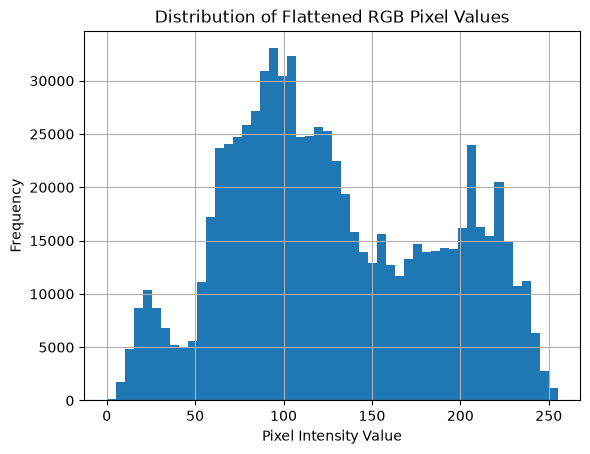

In [5]:
flattened_values = img_cv2.flatten()

print("Original image shape:", img_cv2.shape)
print("Flattened shape:", flattened_values.shape)

# Plot distribution of all RGB values together
plt.hist(flattened_values, bins=50, range=(0, 255))
plt.title("Distribution of Flattened RGB Pixel Values")
plt.xlabel("Pixel Intensity Value")
plt.ylabel("Frequency")
plt.grid(True) 
plt.show()

# Display Images

## Function Notes: Basic Display

- plt.figure: Creates a new figure window.
  Syntax: `plt.figure(figsize=(w, h))`
- plt.imshow: Displays an image array.
  Syntax: `plt.imshow(image, cmap=...)`
- plt.axis: Controls axis visibility/limits.
  Syntax: `plt.axis('off')`
- plt.title: Sets figure title.
  Syntax: `plt.title('text')`
- plt.show: Renders the current figure.
  Syntax: `plt.show()`

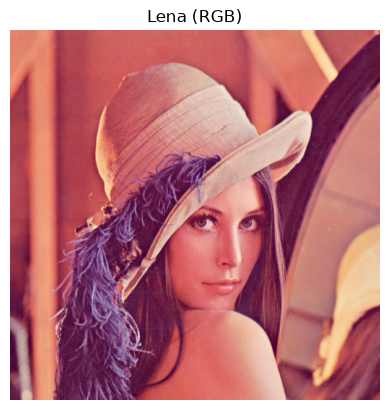

In [6]:
plt.figure()
plt.imshow(img_mpl)
plt.axis('off')
plt.title('Lena (RGB)')
plt.show()

# Image Channels

<img src="https://upload.wikimedia.org/wikipedia/commons/2/28/RGB_illumination.jpg" alt="Result3" style="width:300px;"/>

## RGB Channels

An RGB image has three channels: red, green, and blue. RGB channels roughly follow the color receptors in the human eye, and are used in computer displays and image scanners.

Source: [Wikipedia](https://en.wikipedia.org/wiki/Channel_(digital_image)#:~:text=RGB%20images,-An%20RGB%20image&text=If%20the%20RGB%20image%20is,intensities%20between%200%20and%20255.)

<img src="https://i.imgur.com/g0R7AD3.png" alt="Result3" style="height: 300px; width:300px;"/>

## Function Notes: Subplots and Axes

- plt.subplots: Creates a figure and multiple axes in one call.
  Syntax: `fig, (ax1, ax2, ...) = plt.subplots(rows, cols, figsize=(w, h))`
- Axes.imshow: Displays data on a specific subplot axis.
  Syntax: `ax.imshow(image, cmap=...)`
- Axes.set_title: Sets title for a specific subplot.
  Syntax: `ax.set_title('text')`

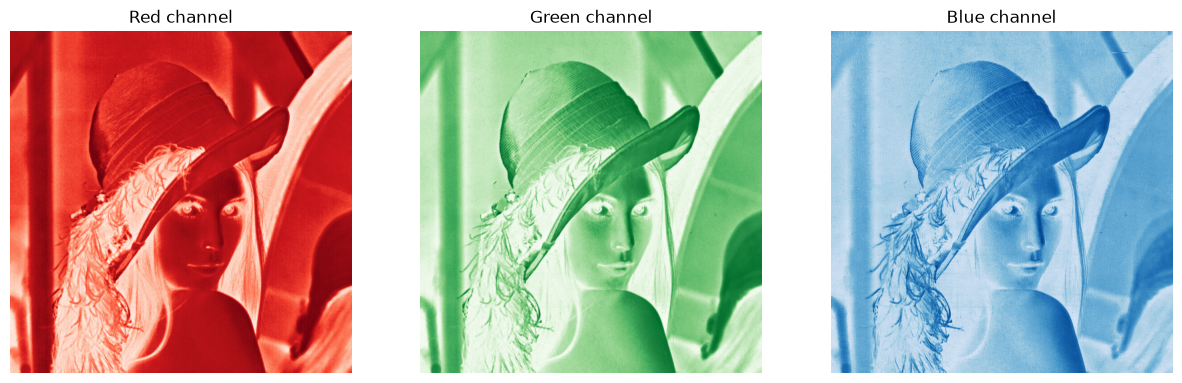

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(img_mpl[:, :, 0], cmap='Reds')
ax2.imshow(img_mpl[:, :, 1], cmap='Greens')
ax3.imshow(img_mpl[:, :, 2], cmap='Blues')

ax1.axis('off')
ax2.axis('off')
ax3.axis('off')

ax1.set_title('Red channel')
ax2.set_title('Green channel')
ax3.set_title('Blue channel')
plt.show()

# Matplotlib vs cv2 Numpy Arrays

- cv2 reads images in BGR order.
- matplotlib displays images in RGB order.

## Function Notes: Color Conversion

- cv2.cvtColor: Converts images between color spaces (e.g., BGR to RGB).
  Syntax: `converted = cv2.cvtColor(src, code)`

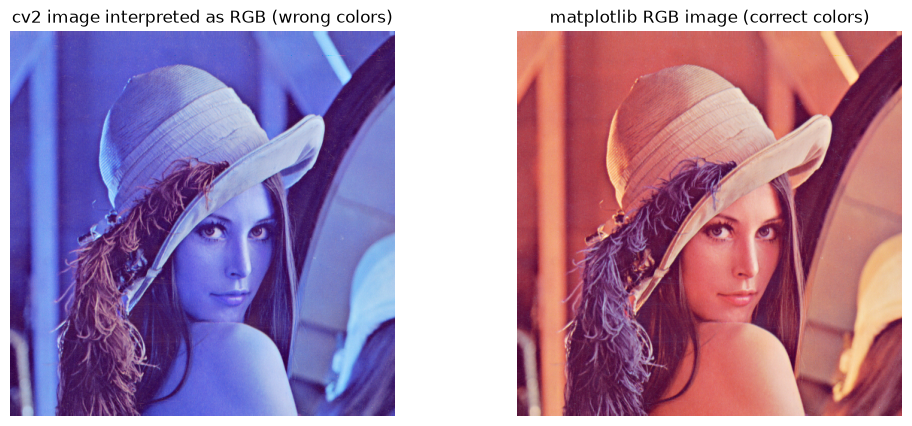

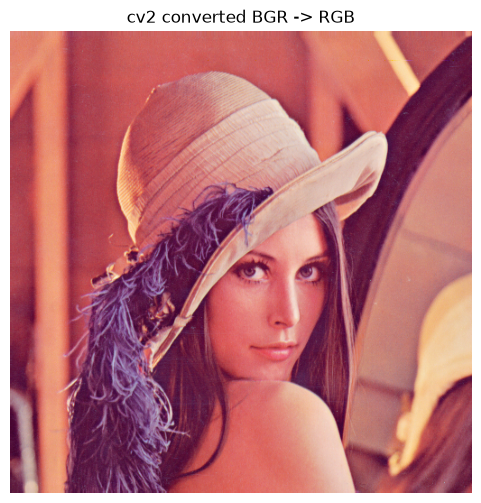

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(img_cv2)
ax2.imshow(img_mpl)

ax1.axis('off')
ax2.axis('off')
ax1.set_title('cv2 image interpreted as RGB (wrong colors)')
ax2.set_title('matplotlib RGB image (correct colors)')
plt.show()

img_cv2_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_cv2_rgb)
ax.axis('off')
ax.set_title('cv2 converted BGR -> RGB')
plt.show()

# Image Manipulation

## cv2 Notes: cv2.cvtColor

- Description: Converts an image from one color space to another.
- In this section: converts Lena from RGB to Grayscale.
- Syntax: `converted = cv2.cvtColor(src, code)`
- Example: `img_gray = cv2.cvtColor(img_mpl, cv2.COLOR_RGB2GRAY)`

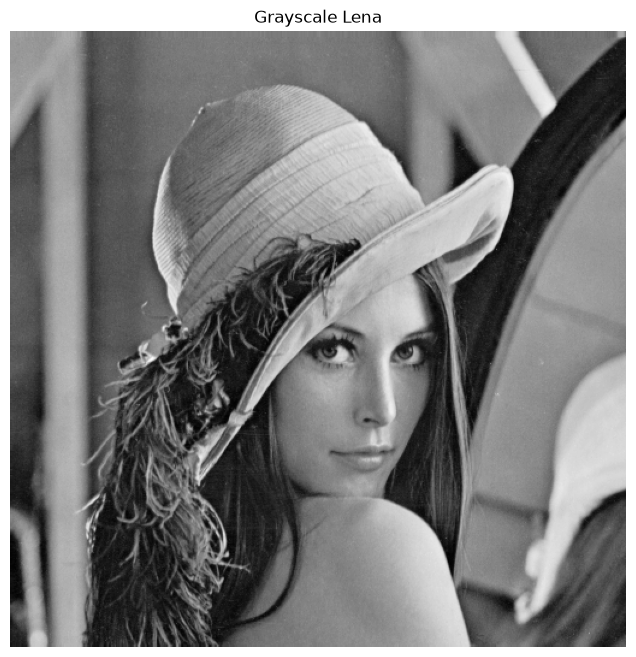

In [9]:
img_gray = cv2.cvtColor(img_mpl, cv2.COLOR_RGB2GRAY)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_gray, cmap='gray')
ax.axis('off')
ax.set_title('Grayscale Lena')
plt.show()

# Resizing and Scaling

## Function Notes: Geometric Transformations

- cv2.resize: Resizes an image by scale factors or target size.
  Syntax: `dst = cv2.resize(src, dsize, fx=..., fy=..., interpolation=...)`


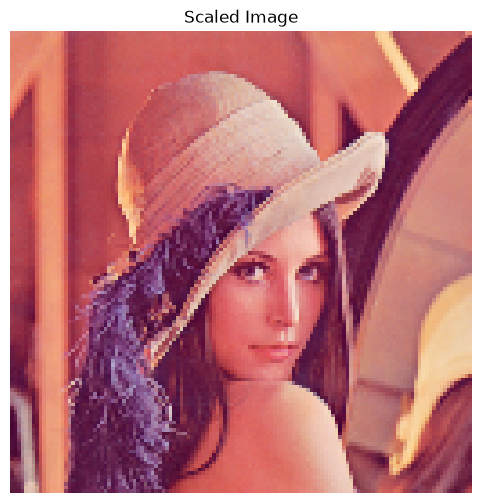

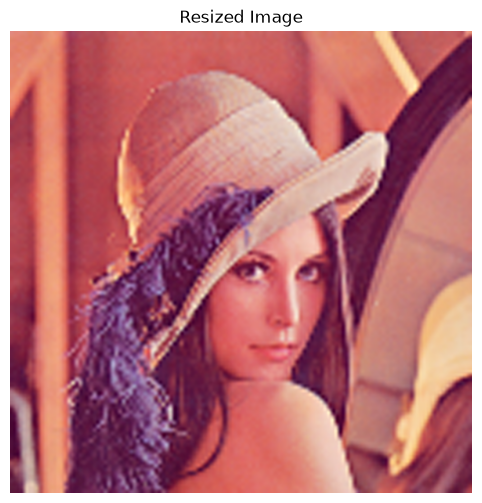

In [ ]:
img_scaled = cv2.resize(img_mpl, None, fx=0.25, fy=0.25)
img_scaled2 = cv2.resize(img_mpl, (128,128))
img_resized = cv2.resize(img_scaled, (512,512), interpolation=cv2.INTER_CUBIC)
img_resized2 = cv2.resize(img_scaled, None, fx=4.0, fy=4.0, interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(10, 6))
plt.imshow(img_scaled)
plt.title("Scaled Image")
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(img_resized)
plt.title("Resized Image")
plt.axis('off')
plt.show()

# Cropping Image Region

## Function Notes: Cropping Image Region

- NumPy slicing: Crops a region using row and column index ranges.
  Syntax: `crop = image[y1:y2, x1:x2]`
- image.shape: Gets image dimensions for dynamic crop coordinates.
  Syntax: `h, w = image.shape[:2]`
- int: Converts computed coordinates to integer pixel indices.
  Syntax: `i = int(value)`

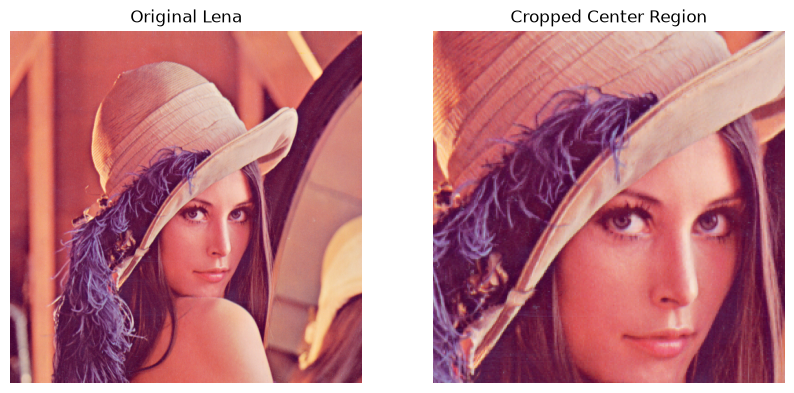

In [37]:
h, w = img_mpl.shape[:2]
# Crop a center region.
y1, y2 = int(h * 0.25), int(h * 0.75)
x1, x2 = int(w * 0.25), int(w * 0.75)
img_crop = img_mpl[y1:y2, x1:x2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_mpl)
ax1.set_title('Original Lena')
ax1.axis('off')

ax2.imshow(img_crop)
ax2.set_title('Cropped Center Region')
ax2.axis('off')
plt.show()

# Contrast Stretching

## Function Notes: Contrast Enhancement

- np.percentile: Returns percentile values from an array.
  Syntax: `p = np.percentile(a, q)`
- np.clip: Limits values into a specified range.
  Syntax: `clipped = np.clip(a, a_min, a_max)`
- cv2.equalizeHist: Performs histogram equalization on a grayscale image.
  Syntax: `eq = cv2.equalizeHist(gray_image)`

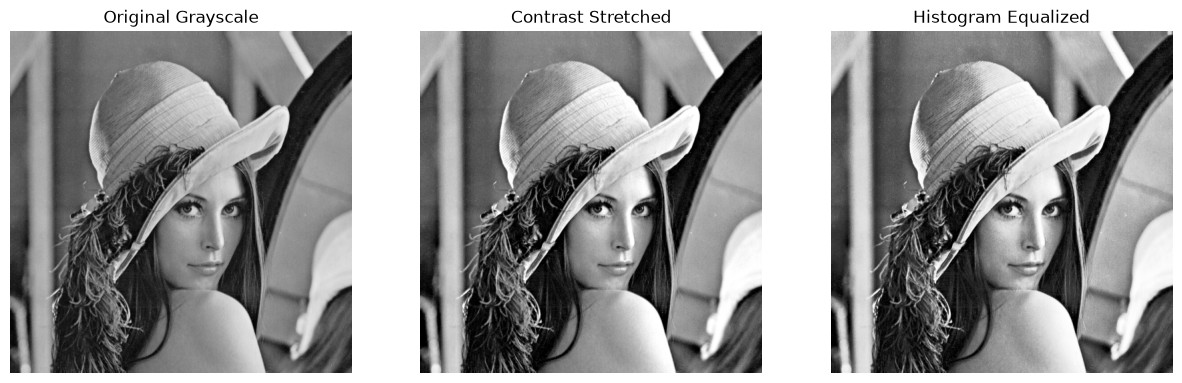

In [38]:
# Stretch grayscale intensities to the full [0, 255] range.
p2, p98 = np.percentile(img_gray, (2, 98))
img_stretched = np.clip((img_gray - p2) * 255.0 / (p98 - p2 + 1e-8), 0, 255).astype(np.uint8)
img_equalized = cv2.equalizeHist(img_gray)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(img_gray, cmap='gray')
ax1.set_title('Original Grayscale')
ax1.axis('off')

ax2.imshow(img_stretched, cmap='gray')
ax2.set_title('Contrast Stretched')
ax2.axis('off')

ax3.imshow(img_equalized, cmap='gray')
ax3.set_title('Histogram Equalized')
ax3.axis('off')
plt.show()

# CV2 Kernels

<img src="https://editor.analyticsvidhya.com/uploads/81269Capture.PNG" alt="imgpixels" style="width:400px;"/>

# Blurr

## Function Notes: Kernel Creation

- np.ones: Creates an array filled with ones (useful for averaging kernels).
  Syntax: `arr = np.ones(shape, dtype=...)`

In [17]:
# Simple blur kernel
kernel_blur = np.ones((3, 3), np.float32) / 9.0
kernel_blur

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]], dtype=float32)

## Function Notes: Linear Filtering

- cv2.filter2D: Applies a custom convolution kernel to an image.
  Syntax: `dst = cv2.filter2D(src, ddepth, kernel)`

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

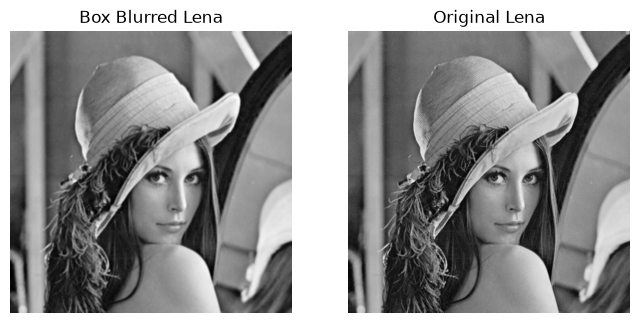

In [18]:
blurred = cv2.filter2D(img_gray, -1, kernel_blur)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))
ax1.imshow(blurred, cmap='gray')
ax1.set_title('Box Blurred Lena')
ax1.axis('off')

ax2.imshow(img_gray, cmap='gray')
ax2.set_title('Original Lena')
ax2.axis('off')

# Edge detection

## Function Notes: Explicit Array Construction

- np.array: Creates a NumPy array from Python lists/tuples.
  Syntax: `arr = np.array(object, dtype=...)`

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

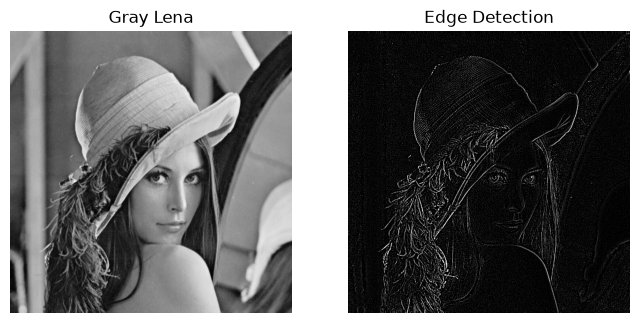

In [15]:
# edge detection kernel
kernel_edge_dectect = np.array([[-1, -1, -1],
                           [-1,  8, -1],
                           [-1, -1, -1]])


edges = cv2.filter2D(img_gray, -1, kernel_edge_dectect)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))
ax1.imshow(img_gray, cmap='gray')
ax1.set_title('Gray Lena')
ax1.axis('off')

ax2.imshow(edges, cmap='gray')
ax2.set_title('Edge Detection')
ax2.axis('off')

# Sharpening

## Function Notes: Linear Filtering

- cv2.filter2D: Applies a custom convolution kernel to an image.
  Syntax: `dst = cv2.filter2D(src, ddepth, kernel)`

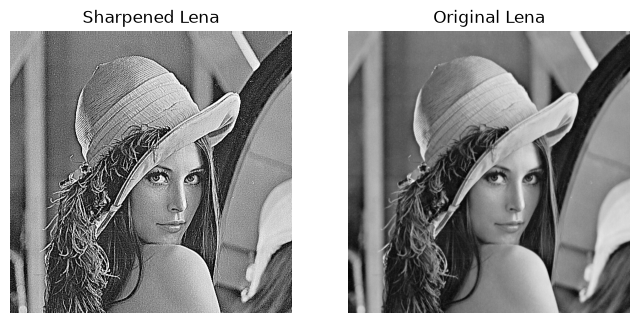

In [21]:
# Sharpening kernel (Laplacian filter)
kernel_sharpen = np.array([[-1, -1, -1],
                           [-1,  9, -1],
                           [-1, -1, -1]])
sharpened = cv2.filter2D(img_gray, -1, kernel_sharpen)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))
ax1.imshow(sharpened, cmap='gray')
ax1.set_title('Sharpened Lena')
ax1.axis('off')
ax2.imshow(img_gray, cmap='gray')
ax2.set_title('Original Lena')
ax2.axis('off')
plt.show()


# Commonly Used CV2 Functions

## Function Notes: Gaussian Smoothing

- cv2.GaussianBlur: Applies Gaussian blur with a chosen kernel size.
  Syntax: `dst = cv2.GaussianBlur(src, ksize, sigmaX)`

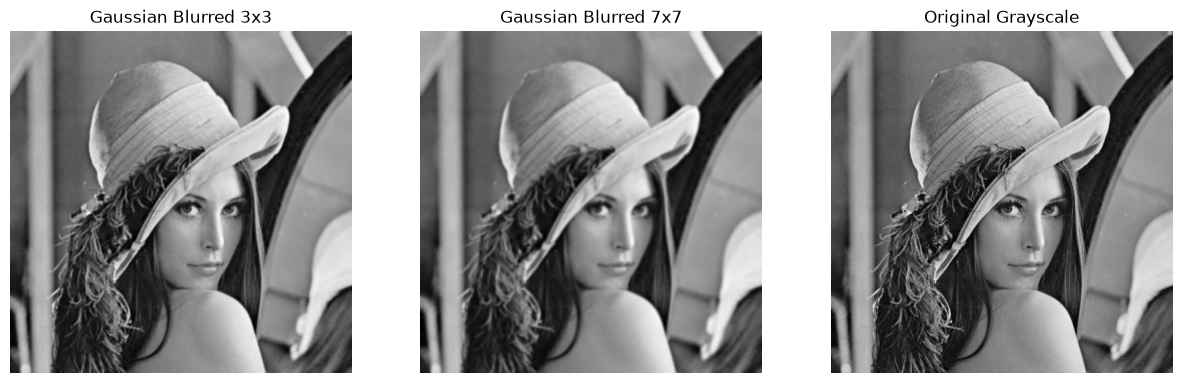

In [22]:
# Gaussian blur
Gau_blurred3x3 = cv2.GaussianBlur(img_gray, (3, 3), 0)
Gau_blurred7x7 = cv2.GaussianBlur(img_gray, (7, 7), 0)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(Gau_blurred3x3, cmap='gray')
ax1.set_title('Gaussian Blurred 3x3')
ax1.axis('off')

ax2.imshow(Gau_blurred7x7, cmap='gray')
ax2.set_title('Gaussian Blurred 7x7')
ax2.axis('off')

ax3.imshow(img_gray, cmap='gray')
ax3.set_title('Original Grayscale')
ax3.axis('off')
plt.show()

## Function Notes: Weighted Blending (Unsharp Masking)

- cv2.addWeighted: Blends two images using weighted sums.
  Syntax: `dst = cv2.addWeighted(src1, alpha, src2, beta, gamma)`

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

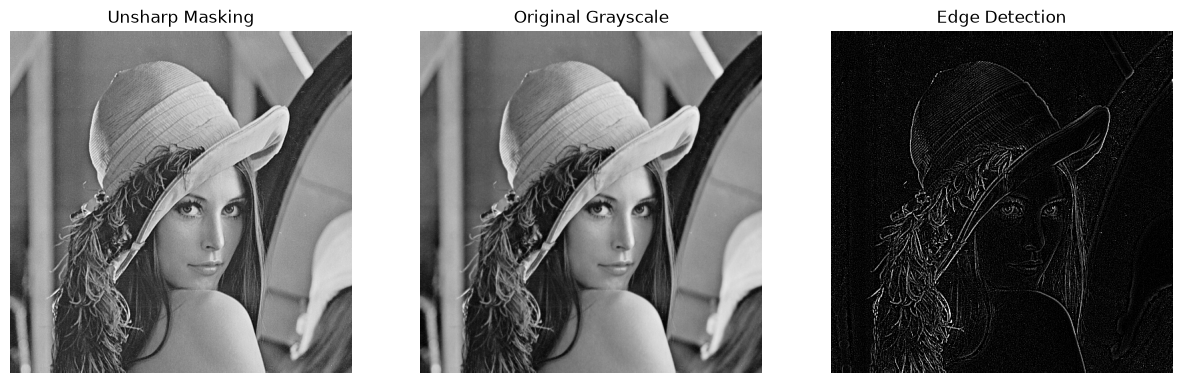

In [23]:
# Sharpening - Unsharp Masking
Gau_blurred5x5 = cv2.GaussianBlur(img_gray, (5, 5), 0)
# edges = cv2.filter2D(img_gray, -1, kernel_edge_dectect)


# Apply the unsharp mask formula: 
# alpha = 1.0 + amount  # Weight for the original image
# beta = -amount       # Weight for the blurred image
# gamma = 0            # Scalar offset added to the result
# alpha = (amount + 1) -> 2.0 means amount is 1.0
# beta = -amount -> -1.0
sharpened_UM = cv2.addWeighted(img_gray, 2.0, Gau_blurred5x5, -1.0, 0)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(sharpened_UM, cmap='gray')
ax1.set_title('Unsharp Masking')
ax1.axis('off')

ax2.imshow(img_gray, cmap='gray')
ax2.set_title('Original Grayscale')
ax2.axis('off')

ax3.imshow(edges, cmap='gray')
ax3.set_title('Edge Detection')
ax3.axis('off')

# Canny Edge Detection

## Function Notes: Canny Edges

- cv2.Canny: Detects edges using gradient thresholds.
  Syntax: `edges = cv2.Canny(image, threshold1, threshold2)`

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

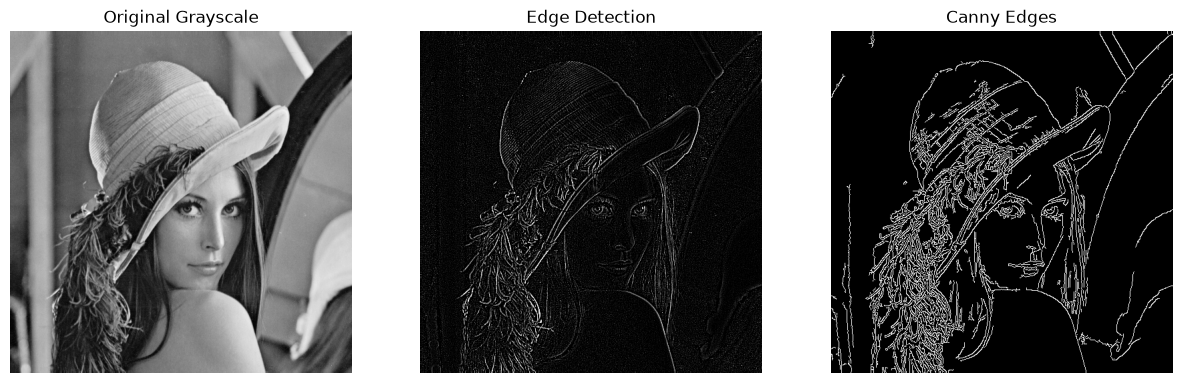

In [24]:
# Canny edge detection
edges_canny = cv2.Canny(img_gray, 50, 150)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(img_gray, cmap='gray')
ax1.set_title('Original Grayscale')
ax1.axis('off')

ax2.imshow(edges, cmap='gray')
ax2.set_title('Edge Detection')
ax2.axis('off')

ax3.imshow(edges_canny, cmap='gray')
ax3.set_title('Canny Edges')
ax3.axis('off')

# Save Image

## Function Notes: Saving Images

- plt.imsave: Saves an array as an image using matplotlib.
  Syntax: `plt.imsave(fname, arr, cmap=...)`
- cv2.imwrite: Writes an image array to disk using OpenCV.
  Syntax: `cv2.imwrite(filename, img)`

In [35]:
# blurred = cv2.filter2D(img_gray, -1, kernel_blur)
# plt.imsave('lena_blurred_mpl.png', blurred)
plt.imsave('lena_blurred_mpl.png', blurred, cmap='gray')
cv2.imwrite('lena_blurred_cv2.png', cv2.cvtColor(blurred, cv2.COLOR_GRAY2BGR))

# img_resized = cv2.resize(img_scaled, (512,512), interpolation=cv2.INTER_CUBIC)
cv2.imwrite('lena_resized.png', img_resized)

print('Saved: lena_blurred_mpl.png, lena_blurred_cv2.png, and lena_resized.png')

Saved: lena_blurred_mpl.png, lena_blurred_cv2.png, and lena_resized.png
